In [1]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantum_algorithms as qa


In [2]:
# Experiment sets

shots = 4096
n_values = [1, 3, 5]
p_values = np.arange(0, 1.01, 0.05)

functions = {
    "constant_1": qa.deutsch_jozsa.f_constant_1,
    "constant_0": qa.deutsch_jozsa.f_constant_0,
    "balanced_parity": qa.deutsch_jozsa.f_balanced_parity,
}

error_positions = {
    "D(P)1_before_H": qa.depolarizing.deutsch_jozsa_depolarizing1,
    "D(P)2_after_first_H": qa.depolarizing.deutsch_jozsa_depolarizing2,
    "D(P)3_after_oracle": qa.depolarizing.deutsch_jozsa_depolarizing3,
    "D(P)4_after_final_H": qa.depolarizing.deutsch_jozsa_depolarizing4,
}

def clean_probs(probs):
    probs = np.real(probs)
    probs = np.clip(probs, 0, None)
    probs = probs / np.sum(probs)
    return probs

results = []

for n in n_values:
    print("Running n =", n)

    target_qubit = n // 2

    for function_name, f in functions.items():

        state_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f)

        probs_ref = qa.deutsch_jozsa.measure_probs_first_n(state_ref, n)
        probs_ref = clean_probs(probs_ref)

        samples_ref = qa.deutsch_jozsa.sample_probs(probs_ref, shots)
        P0_ref = samples_ref[0] / shots

        for p in p_values:

            results.append({
                "n": n,
                "p": p,
                "target_qubit": target_qubit,
                "function": function_name,
                "error_position": "no_error",
                "P0": P0_ref,
                "shots": shots,
            })

            for error_name, error_function in error_positions.items():

                rho_error = error_function(n, f, p, target_qubit)

                probs_error = qa.depolarizing.measure_probs_first_n_rho(
                    rho_error,
                    n
                )

                probs_error = clean_probs(probs_error)

                samples_error = qa.deutsch_jozsa.sample_probs(
                    probs_error,
                    shots
                )

                P0_error = samples_error[0] / shots

                results.append({
                    "n": n,
                    "p": p,
                    "target_qubit": target_qubit,
                    "function": function_name,
                    "error_position": error_name,
                    "P0": P0_error,
                    "shots": shots,
                })

df_dep = pd.DataFrame(results)

df_dep.head()

Running n = 1
Running n = 3
Running n = 5


,n,p,target_qubit,function,error_position,P0,shots
0,1,0.0,0,constant_1,no_error,1.0,4096
1,1,0.0,0,constant_1,D(P)1_before_H,1.0,4096
2,1,0.0,0,constant_1,D(P)2_after_first_H,1.0,4096
3,1,0.0,0,constant_1,D(P)3_after_oracle,1.0,4096
4,1,0.0,0,constant_1,D(P)4_after_final_H,1.0,4096


In [3]:
df_dep.to_csv("dja_depolarizing_results_shots_1024.csv", index=False)

In [4]:
def plot_depolarizing_positions(df, n_plot, function_plot):

    plot_df = df[
        (df["n"] == n_plot) &
        (df["function"] == function_plot)
    ]

    plt.figure(figsize=(8, 5), dpi=150)

    labels = {
    "no_error": "Ideal circuit",
    "D(P)1_before_H": r"$D_p$ at $E_1$ (before H)",
    "D(P)2_after_first_H": r"$D_p$ at $E_2$ (after first H)",
    "D(P)3_after_oracle": r"$D_p$ at $E_3$ (after oracle)",
    "D(P)4_after_final_H": r"$D_p$ at $E_4$ (after final H)",
    }

    for error_pos, label in labels.items():
        subset = plot_df[plot_df["error_position"] == error_pos]

        plt.plot(
            subset["p"],
            subset["P0"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=label
        )

    plt.xlabel(r"Depolarizing probability $p$", fontsize=12)
    plt.ylabel(r"Probability $P(0\ldots0)$", fontsize=12)
    plt.title(rf"Effect of depolarizing noise on the Deutsch--Jozsa algorithm"
    "\n"
    rf"$\mathrm{{function}}={function_plot},\ n={n_plot},\ "
    rf"\mathrm{{shots}}={shots}$",
    fontsize=13)

    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

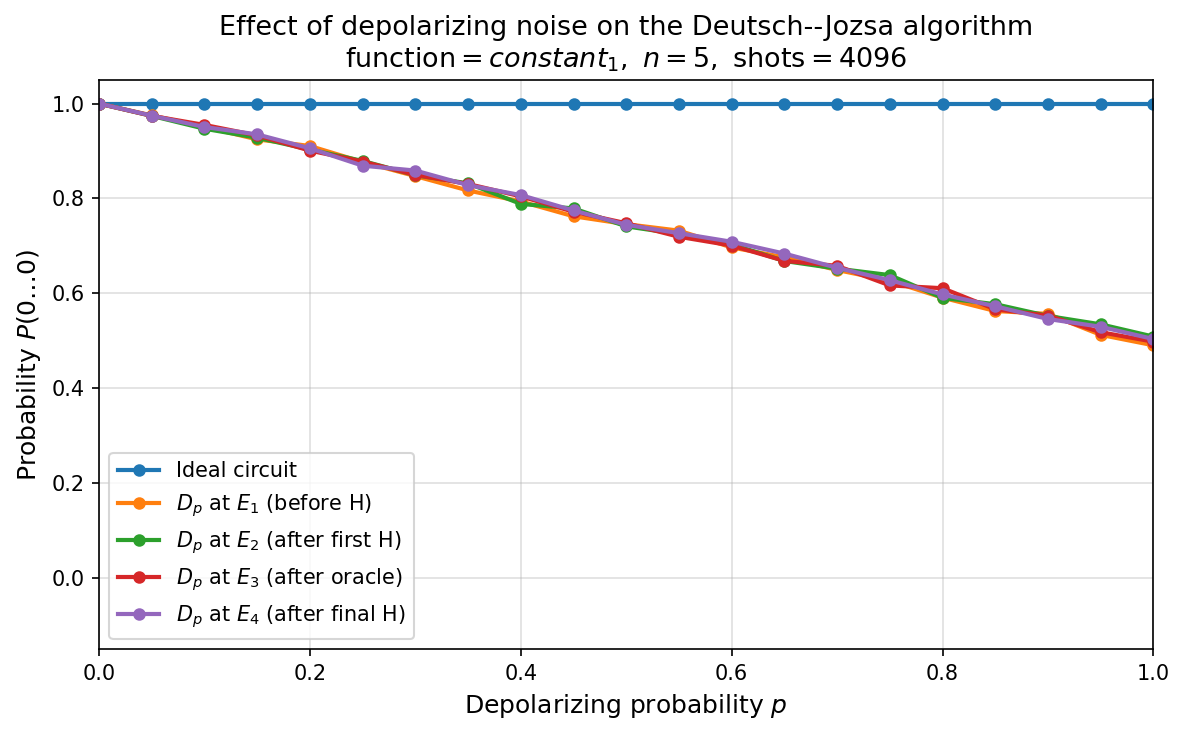

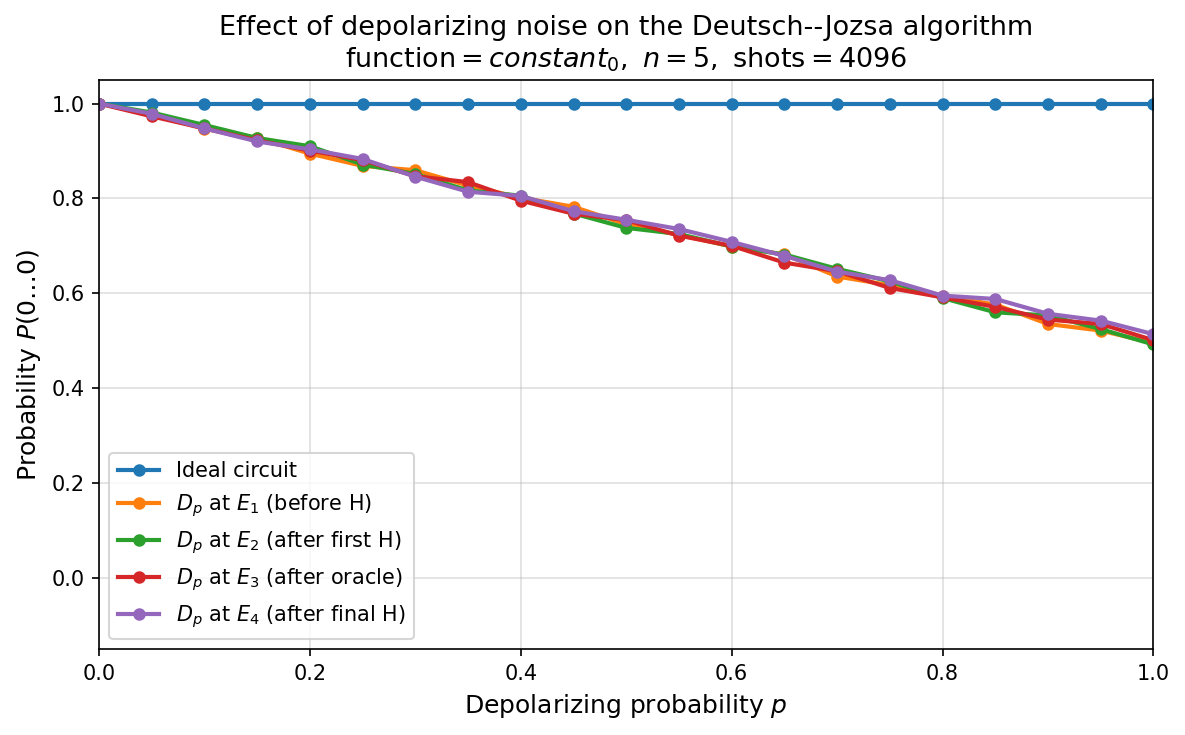

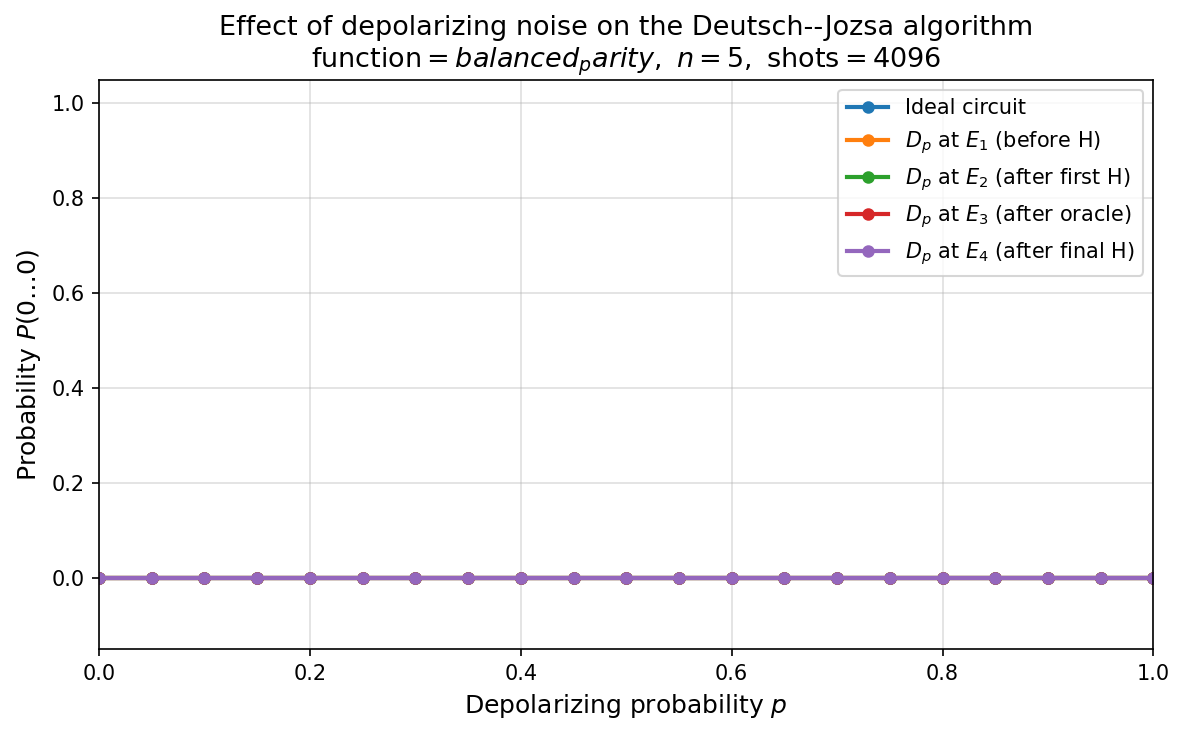

In [5]:
plot_depolarizing_positions(df_dep, n_plot=5, function_plot="constant_1")
plot_depolarizing_positions(df_dep, n_plot=5, function_plot="constant_0")
plot_depolarizing_positions(df_dep, n_plot=5, function_plot="balanced_parity")